In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


In [10]:
df = pd.read_csv('healthcare_dataset.csv')
X = df[['Age', 'Billing Amount']]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.12, min_samples=20)
df['cluster'] = dbscan.fit_predict(x_scaled)

anomalies = df[df['cluster'] == -1]
print("total anomalies:", len(anomalies))
print(anomalies.head())

import numpy as np

unique, counts = np.unique(df['cluster'], return_counts=True)
print(dict(zip(unique, counts)))

total anomalies: 26
                 Name  Age  Gender Blood Type Medical Condition  \
50367   JOSepH vAuGHN   88    Male         B-          Diabetes   
50377  jamES BasS phD   13    Male         O+            Asthma   
50763    noAh RObErTS   15  Female         A+            Cancer   
50823   DEaNnA pALMeR   13    Male        AB-           Obesity   
50908    rOnalD daVis   13    Male         A+           Obesity   

      Date of Admission            Doctor                     Hospital  \
50367        2019-12-31       Wanda Barry       Chaney, Cook Tyler and   
50377        2020-12-30  Jennifer Hammond    Pollard Wallace, Sims and   
50763        2022-02-20       Keith Henry               Sons and Heath   
50823        2020-09-20    Barbara Butler  and Sanchez Phillips, Brown   
50908        2023-12-06    Shannon Butler    Kelly, and Gomez Williams   

      Insurance Provider  Billing Amount  Room Number Admission Type  \
50367         Blue Cross     1042.537177          143       

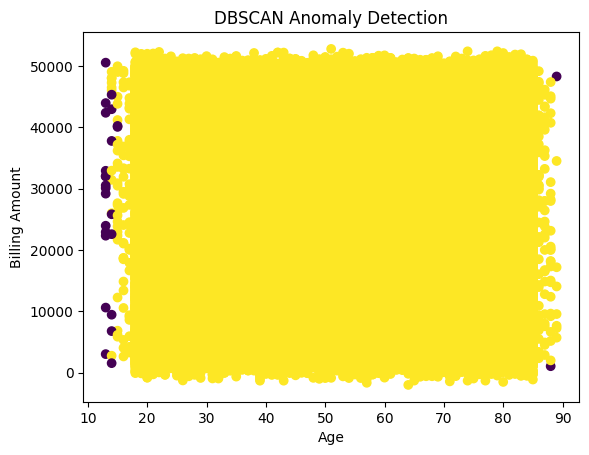

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df['Age'], df['Billing Amount'], c=df['cluster'], cmap='viridis')
plt.xlabel("Age")
plt.ylabel("Billing Amount")
plt.title("DBSCAN Anomaly Detection")
plt.show()